# 🫁 AI Pneumonia Detection: Custom CNN Architecture
**Project Scope:** To build, train, and evaluate a custom Convolutional Neural Network (CNN) from scratch for detecting Pneumonia from chest X-ray images.

## 1. Setup and GPU Configuration
To begin, I imported the required deep learning libraries. Since the model is trained from scratch, computational efficiency is important. I configured TensorFlow to use Kaggle's dual NVIDIA T4 GPUs via `MirroredStrategy`, enabling parallel processing and faster training.

In [2]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers, models, callbacks

# Setup MirroredStrategy to use BOTH T4 GPUs simultaneously
strategy = tf.distribute.MirroredStrategy()
print(f"Number of GPUs being used: {strategy.num_replicas_in_sync}")

2026-05-12 04:18:51.758786: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778559531.986093      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778559532.054047      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778559532.587246      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778559532.587284      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778559532.587287      57 computation_placer.cc:177] computation placer alr

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs being used: 2


I0000 00:00:1778559560.160814      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778559560.166859      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 2. Data Pipeline and Preprocessing
I established the data pipelines using `image_dataset_from_directory`. Since this model is built from scratch, I loaded the dataset in **grayscale** (`color_mode='grayscale'`) because X-rays do not contain color information. This reduces memory usage and speeds up training. I also applied `AUTOTUNE` to optimize the data pipeline and improve GPU utilization.

In [16]:
# Exact paths to your dataset folders
base_dir = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Scale batch size for 2 GPUs (32 per GPU = 64 total)
BATCH_SIZE = 32 * strategy.num_replicas_in_sync 
IMG_SIZE = (224, 224)

# 1. Load Training Data
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='grayscale' # X-rays are in grayscale
)

# 2. Load Validation Data (Used to monitor training)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='grayscale'
)

# 3. Load Testing Data (Used for final evaluation)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='grayscale'
)

# Optimize datasets for faster pipeline performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


## 3. Exploratory Data Analysis (EDA)
Before designing the network, I visualized the class distribution to better understand the dataset. Since the dataset is imbalanced (more Pneumonia cases than Normal), evaluation will focus on Precision, Recall, and Confusion Matrix instead of relying only on accuracy.

/tmp/ipykernel_57/3449559277.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Normal', 'Pneumonia'], y=[normal_count, pneumonia_count],


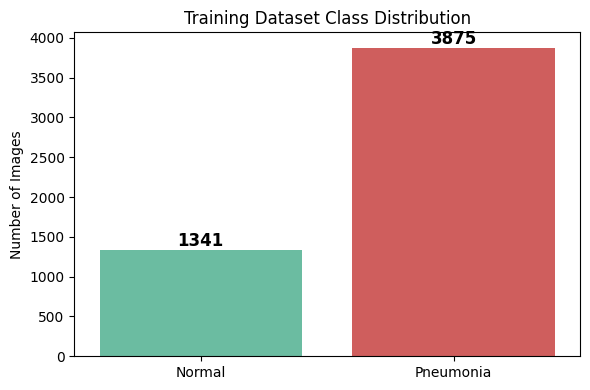

In [17]:
normal_count = len(os.listdir(os.path.join(train_dir, 'NORMAL')))
pneumonia_count = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=['Normal', 'Pneumonia'], y=[normal_count, pneumonia_count], 
            palette=['#5DCAA5', '#E24B4A'], ax=ax)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Training Dataset Class Distribution')
ax.set_ylabel('Number of Images')
plt.tight_layout()
plt.show()

## 4. Custom CNN Architecture Design
Rather than relying on pre-trained weights immediately, I designed a Sequential Convolutional Neural Network (CNN) from scratch to serve as a powerful baseline feature extractor. 

**High-Level Architecture Breakdown:**
1. **Input & Normalization:** The network ingests `224x224` grayscale matrices. I included a `Rescaling(1./255)` layer to normalize pixel values between 0 and 1, which stabilizes the gradients and significantly speeds up network convergence.
2. **On-the-Fly Augmentation:** To combat the limited size of the pediatric dataset, I integrated data augmentation directly into the model pipeline. Slight rotations and zooms force the model to learn invariant features rather than memorizing the exact pixel locations of the training images.
3. **Hierarchical Feature Extraction (Conv Blocks):** I structured four alternating `Conv2D` and `MaxPooling2D` blocks, progressively increasing the filter depth (32 -> 64 -> 128 -> 128). 
   * The **early layers** detect rudimentary structures like the curvature of the rib cage and diaphragm.
   * The **deeper layers** capture complex, high-level textures such as the cloudy opacities (infiltrates) indicative of pneumonia.
   * **MaxPooling** reduces spatial dimensions, cutting down computational load while ensuring the model remains robust to minor shifts in the X-ray positioning.
4. **Classification Head:** I flattened the 2D feature maps into a 1D vector, passing it through a dense 512-neuron layer. To prevent the model from aggressively overfitting to the training data, I applied an aggressive `Dropout(0.5)` layer (randomly deactivating 50% of the neurons during each epoch). Finally, a single neuron with a `Sigmoid` activation function outputs the binary diagnostic probability.

In [3]:
def create_model():
    model = models.Sequential([
        # Input layer & Rescaling (1 channel for grayscale)
        layers.InputLayer(input_shape=(224, 224, 1)),
        layers.Rescaling(1./255),
        
        # Data Augmentation (Helps generalize the model)
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        # Convolutional Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Convolutional Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Convolutional Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Convolutional Block 4
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Flatten and Dense Layers
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5), # Prevents overfitting
        layers.Dense(1, activation='sigmoid', dtype='float32') # Output: Normal vs Pneumonia
    ])
    
    # Compile the model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
    )
    return model

# Create the model inside the GPU strategy scope so it distributes correctly!
with strategy.scope():
    model = create_model()

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,086,337 (49.92 MB)

 Trainable params: 13,086,337 (49.92 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Model Compilation and Training Strategy
The model is compiled inside the `create_model()` function defined in the previous cell, using the `Adam` optimizer with a learning rate of `1e-4` and gradient clipping (`clipnorm=1.0`) to ensure stable updates. Here I defined the training callbacks and ran the training loop. `EarlyStopping` halts training when validation loss stops improving, while `ReduceLROnPlateau` reduces the learning rate when the model plateaus, helping it converge more precisely.

In [4]:
# Callbacks to prevent overfitting and adjust learning rate dynamically
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

lr_reduction = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    patience=3, 
    factor=0.3, 
    min_lr=0.000001
)

EPOCHS = 25

# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, lr_reduction]
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

I0000 00:00:1777797948.160548    1107 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777797949.132110    1105 cuda_dnn.cc:529] Loaded cuDNN version 91002


82/82 ━━━━━━━━━━━━━━━━━━━━ 23s 168ms/step - accuracy: 0.7439 - loss: 0.5816 - precision: 0.7506 - recall: 0.9846 - val_accuracy: 0.6250 - val_loss: 0.6244 - val_precision: 0.5833 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 2/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.8313 - loss: 0.3828 - precision: 0.8408 - recall: 0.9574 - val_accuracy: 0.8750 - val_loss: 0.4579 - val_precision: 0.8750 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 3/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.9001 - loss: 0.2458 - precision: 0.9282 - recall: 0.9394 - val_accuracy: 0.8125 - val_loss: 0.4089 - val_precision: 0.8571 - val_recall: 0.7500 - learning_rate: 1.0000e-04
Epoch 4/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.9184 - loss: 0.2086 - precision: 0.9449 - recall: 0.9463 - val_accuracy: 0.9375 - val_loss: 0.3284 - val_precision: 0.8889 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/25
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy

## 6. Visualizing Training Performance
I plotted training and validation accuracy and loss to evaluate how well the model is learning and to check for overfitting.

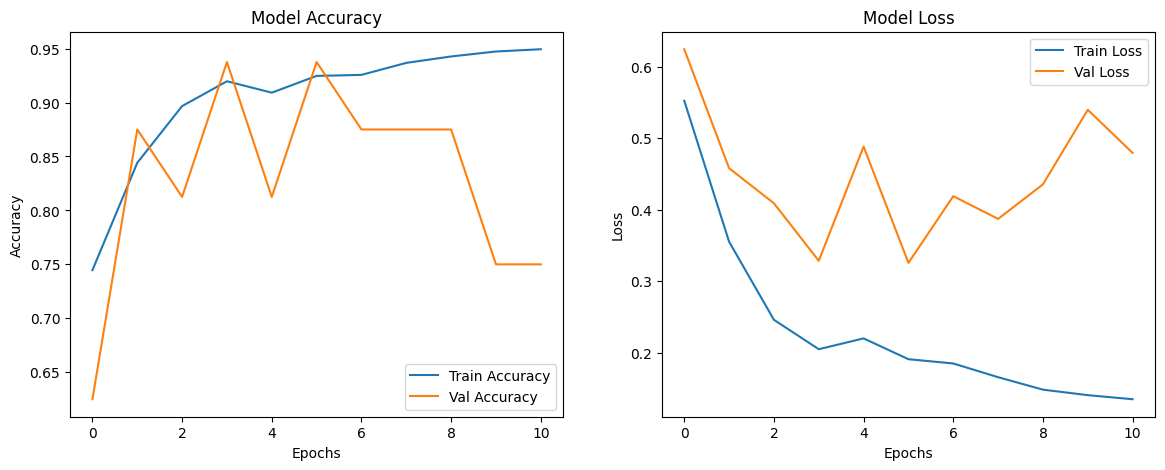

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Plot Loss
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.show()

## 7. Final Evaluation on the Test Set
I evaluated the trained model on the completely unseen `test_dataset` using Keras' built-in `model.evaluate()` function. This returns overall performance metrics including loss, accuracy, precision, and recall, providing a quick summary of how well the model generalizes to new data.

In [6]:
# Evaluate the model on the unseen Test data
print("Evaluating on Test Dataset...")
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_dataset)

print(f"\n--- Final Results on Test Set ---")
print(f"Accuracy:  {test_accuracy * 100:.2f}%")
print(f"Precision: {test_precision * 100:.2f}%")
print(f"Recall:    {test_recall * 100:.2f}%")

Evaluating on Test Dataset...
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - accuracy: 0.9175 - loss: 0.2373 - precision: 0.6051 - recall: 0.6161 

--- Final Results on Test Set ---
Accuracy:  90.06%
Precision: 94.32%
Recall:    89.49%


## 8. Confusion Matrix & Classification Report
Beyond simple accuracy, I analyzed the model's predictions in detail using a Confusion Matrix and a full classification report. In medical AI, minimizing **False Negatives** (missed Pneumonia cases) is critical — a missed diagnosis carries a higher cost than a false alarm. The metrics below reflect how well the model handles this tradeoff:

- **Precision:** Of all Pneumonia predictions, how many were correct (minimizing False Positives).
- **Recall (Sensitivity):** Of all actual Pneumonia cases, how many were caught (minimizing False Negatives).
- **F1-Score:** The harmonic mean of Precision and Recall, giving a balanced view of model performance.

Generating predictions for the Confusion Matrix...


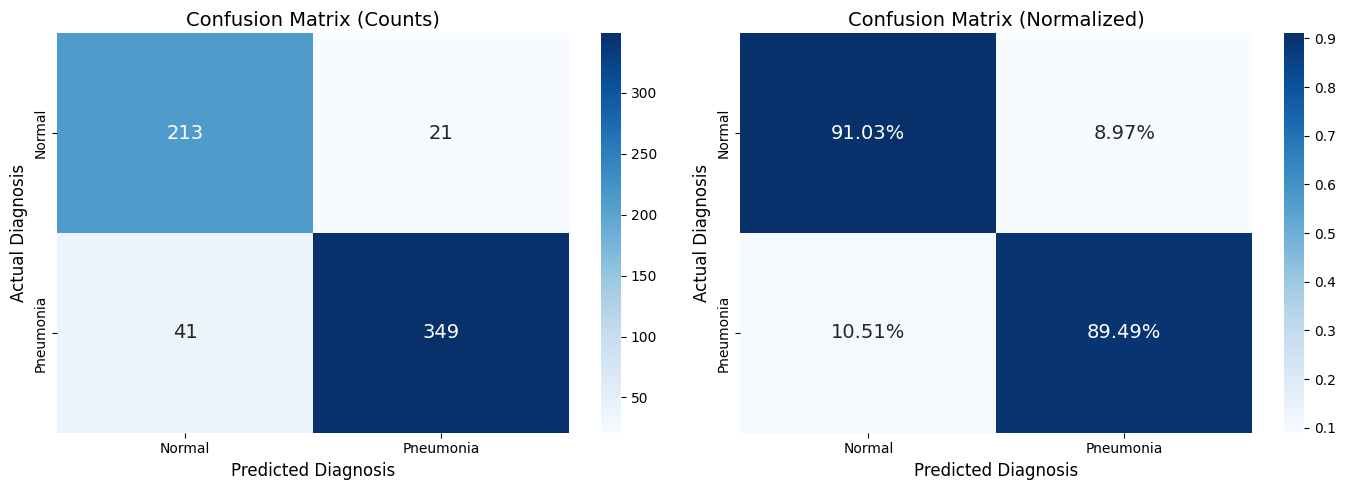


--- Detailed Classification Report ---
              precision    recall  f1-score   support

      Normal       0.84      0.91      0.87       234
   Pneumonia       0.94      0.89      0.92       390

    accuracy                           0.90       624
   macro avg       0.89      0.90      0.90       624
weighted avg       0.90      0.90      0.90       624



In [18]:
test_dataset = test_dataset.unbatch().batch(64)  # resets the iterator

print("Generating predictions for the Confusion Matrix...")
y_true = []
y_pred_probs = []
for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            annot_kws={"size": 14})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14)
axes[0].set_ylabel('Actual Diagnosis', fontsize=12)
axes[0].set_xlabel('Predicted Diagnosis', fontsize=12)
# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            annot_kws={"size": 14})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14)
axes[1].set_ylabel('Actual Diagnosis', fontsize=12)
axes[1].set_xlabel('Predicted Diagnosis', fontsize=12)
plt.tight_layout()
plt.show()
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

## 9. ROC-AUC Curve
The ROC curve plots the True Positive Rate against the False Positive Rate at every classification threshold. The AUC (Area Under the Curve) summarises this into a single score — a perfect model scores 1.0, and random guessing scores 0.5. For medical screening, a high AUC confirms the model reliably separates Pneumonia from Normal cases across all thresholds, not just at the default 0.5 cutoff.

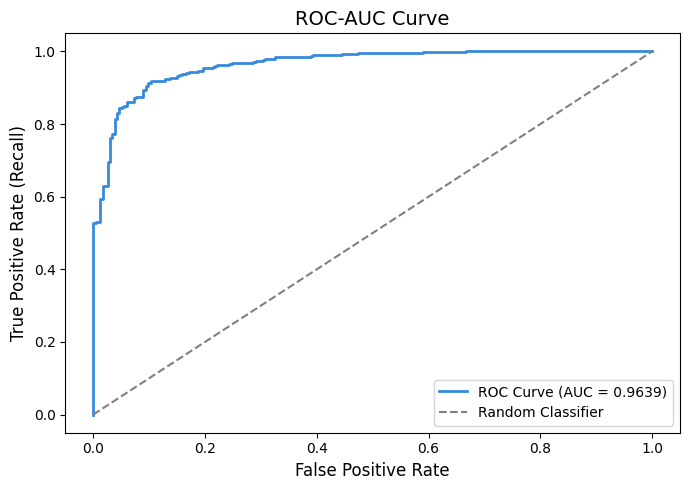

AUC Score: 0.9639


In [19]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#378ADD', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC-AUC Curve', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

## 10. Real-World Inference Demo
To demonstrate real-world usage, I implemented a function that loads a chest X-ray image and generates a prediction with a confidence score. The image is preprocessed to match the exact training conditions — resized to `224x224` and loaded in **grayscale** — since any mismatch in preprocessing at inference time would produce unreliable results. The output shows the X-ray alongside a probability bar for both classes, making the model's confidence visually clear.

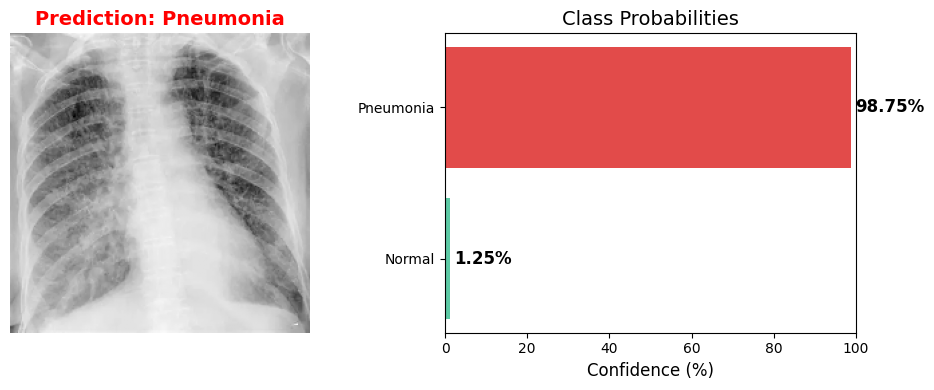

In [20]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

def predict_single_image(img_path, trained_model):
    """Load an image, preprocess it, and make a prediction."""

    # Load image (224x224 grayscale — must match training preprocessing)
    img = image.load_img(img_path, target_size=(224, 224), color_mode='grayscale')
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = trained_model.predict(img_batch, verbose=0)
    pneumonia_prob = prediction[0][0]
    normal_prob = 1 - pneumonia_prob

    diagnosis = "Pneumonia" if pneumonia_prob > 0.5 else "Normal"
    color = 'red' if diagnosis == "Pneumonia" else 'green'

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Left — X-ray image
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f"Prediction: {diagnosis}", fontsize=14,
                      fontweight='bold', color=color)
    axes[0].axis('off')

    # Right — confidence bar chart
    classes = ['Normal', 'Pneumonia']
    probs = [normal_prob * 100, pneumonia_prob * 100]
    bar_colors = ['#5DCAA5', '#E24B4A']
    bars = axes[1].barh(classes, probs, color=bar_colors)
    axes[1].set_xlim(0, 100)
    axes[1].set_xlabel('Confidence (%)', fontsize=12)
    axes[1].set_title('Class Probabilities', fontsize=14)
    for bar, prob in zip(bars, probs):
        axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                     f'{prob:.2f}%', va='center', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

# Run prediction
my_google_image = '/kaggle/input/datasets/tejas5112/pnuemonia/OIP.webp'
predict_single_image(my_google_image, model)

## 11. Model Saving
After training and evaluation, I saved the trained model using Keras' built-in `model.save()` function. This allows the model to be reused later for inference or deployment without retraining.

In [25]:
model.save('pneumonia_detection_model.keras')